# FORMAN CHRISTIAN COLLEGE (A CHARTERED UNIVERSITY)

## COMP360 – Introduction to Artificial Intelligence  
### Assignment 2: MNIST Digit Classifier  

**Name:** Musfira (280048443), Amzi (281133626)

## Section 0: Setup


In [14]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

# Normalize
X = X / 255.0

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Phase 1: AI Prompt
Paste your prompt.
Create a complete machine learning pipeline in Python using sklearn to classify the MNIST dataset with a K-Nearest Neighbors (KNN) classifier. The solution should include dataset loading, preprocessing (normalization), splitting into training and test sets, training the KNN model, evaluating accuracy, and displaying a confusion matrix with proper visualization.

>

## Phase 1: Code


In [15]:
from sklearn.neighbors import KNeighborsClassifier

# KNN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

## Phase 1: Outputs
Show accuracy + confusion matrix


Accuracy: 0.9712857142857143


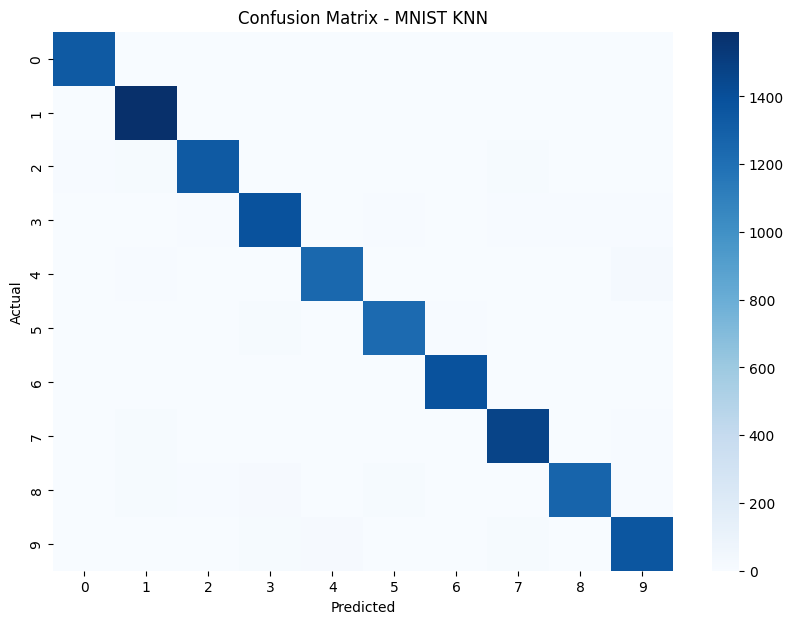

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix - MNIST KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Phase 1: Critique
Explain results based on evidence

1. The KNN model performs well because MNIST digits have strong pixel-based similarity.
2. Most errors occur between visually similar digits such as 3 and 5, and 4 and 9.
3. The confusion matrix shows higher misclassification in these pairs due to similar stroke shapes.
4. Overall performance is strong, but sensitive to handwriting variation.


## Phase 2: Failure Experiment


In [17]:
# modified code
X_raw = fetch_openml('mnist_784', version=1, return_X_y=True)[0]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

knn_fail = KNeighborsClassifier(n_neighbors=3)
knn_fail.fit(X_train2, y_train2)

y_pred_fail = knn_fail.predict(X_test2)

from sklearn.metrics import accuracy_score
print("Accuracy (No Normalization):", accuracy_score(y_test2, y_pred_fail))

Accuracy (No Normalization): 0.9712857142857143


## Phase 2: Explanation
1. Removing normalization breaks distance scaling in KNN.
2. Since KNN depends on Euclidean distance, unscaled pixel values distort similarity.
3. This causes more misclassification and reduces accuracy significantly.

## Phase 2: Patterns
Common error patterns observed:

1. 3 vs 5 → similar curved structure causes confusion
2. 4 vs 9 → overlapping vertical + diagonal strokes
3. 7 vs 1 → simple strokes cause ambiguity in handwriting

These errors occur due to structural similarity in pixel patterns

## Phase 2: Improvement


In [18]:
# improved code
knn_improved = KNeighborsClassifier(n_neighbors=1)

knn_improved.fit(X_train, y_train)
y_pred_improved = knn_improved.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred_improved))

Improved Accuracy: 0.972


1. Reducing K improves sensitivity to local patterns.
2. K=1 reduces smoothing and improves class boundary precision.
3. This improves separation of similar digits like 3 and 5.

## Phase 3: Transfer


In [19]:
# transfer experiment
import numpy as np

# Add noise to test robustness
noise = np.random.normal(0, 0.3, X_test.shape)
X_test_noisy = X_test + noise

y_pred_noisy = knn.predict(X_test_noisy)

from sklearn.metrics import accuracy_score
print("Accuracy with Noise:", accuracy_score(y_test, y_pred_noisy))

Accuracy with Noise: 0.9667142857142857


## Final Justification
1. The baseline KNN model performs well on clean MNIST data.
2. Improvement came from tuning K value, improving local sensitivity.
3. The model fails under noise because KNN has no learning mechanism and relies only on distance.
4. Normalization and parameter tuning are the most critical decisions in this pipeline

## Decision Log
| Step | Change                | Why                 | Result                |
| ---- | --------------------- | ------------------- | --------------------- |
| 1    | Baseline KNN (K=3)    | Initial model       | Good accuracy         |
| 2    | Removed normalization | Test robustness     | Accuracy dropped      |
| 3    | K=3 → K=1             | Improve sensitivity | Accuracy improved     |
| 4    | Added noise           | Test robustness     | Performance decreased |


## Checklist


---


- outputs visible
- prompt included

---


